**Credit Card Fraud Detection**

Dataset Link: https://drive.google.com/file/d/1_SZH9zsMcJsoJg5sDgyvLBhYQw9aJeJA/view?usp=sharing

Highly Imbalanced -- do not rely on accuracy score

**1. Setup**

In [ ]:
# Importing Required dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, average_precision_score, classification_report

In [ ]:
# Configuration
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

**2. Load Dataset**

In [ ]:
df = pd.read_csv("creditcard.csv")

**3. Exploratory Data Analysis (EDA)**

In [ ]:
df.shape

(284807, 31)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [ ]:
# Basic Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Quick Check for encoded columns
for col in df.columns:
  print(df[col].value_counts().head(10))
  print("-"*50)

Time
163152.000    36
64947.000     26
68780.000     25
3767.000      21
3770.000      20
128860.000    19
19912.000     19
140347.000    19
3750.000      19
143083.000    18
Name: count, dtype: int64
--------------------------------------------------
V1
1.246    77
2.056    77
2.053    62
1.302    60
2.040    53
2.085    48
1.333    45
1.018    40
1.335    39
1.315    36
Name: count, dtype: int64
--------------------------------------------------
V2
0.167     77
-0.327    77
0.090     62
-0.607    60
-0.147    53
0.393     48
0.389     45
1.037     40
0.331     39
-0.034    36
Name: count, dtype: int64
--------------------------------------------------
V3
0.488     77
-2.752    77
-1.682    62
-0.682    60
-2.956    53
-4.508    48
-2.166    45
-1.690    40
-2.058    39
-1.090    36
Name: count, dtype: int64
--------------------------------------------------
V4
0.635     77
-0.842    77
0.454     62
-1.905    60
-0.578    53
-0.312    48
-0.307    45
1.315     40
-0.346    39
-0.557  

In [ ]:
# Checking Missing Values
df.isnull().sum().sort_values(ascending=False)

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 1081


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df["Class"].value_counts(normalize=True)*100

,proportion
Class,
0,99.827
1,0.173


**Data is highly imbalanced**

In [ ]:
# Imbalanced Ratio
num_fraud = (df["Class"] == 1).sum()
num_nonfraud = (df["Class"] == 0).sum()
print("Imbalanced ratio (non-fraud : fraud) =", round(num_nonfraud / max(num_fraud, 1), 2))

Imbalanced ratio (non-fraud : fraud) = 577.88


1 fraud transaction to 577 non-fraud Transaction

In [ ]:
# describe stats for key columns
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000,284807.000
mean,94813.860,88.350
std,47488.146,250.120
min,0.000,0.000
25%,54201.500,5.600
50%,84692.000,22.000
75%,139320.500,77.165
max,172792.000,25691.160


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,1.021,0.999,0.995,0.959,0.915,0.876,0.849,0.838,0.814,0.771,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,-4.797,-18.684,-5.792,-19.214,-4.499,-14.130,-25.163,-9.499,-7.214,-54.498,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,-0.762,-0.406,-0.649,-0.426,-0.583,-0.468,-0.484,-0.499,-0.456,-0.212,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,-0.033,0.140,-0.014,0.051,0.048,0.066,-0.066,-0.004,0.004,-0.062,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,0.740,0.618,0.663,0.493,0.649,0.523,0.400,0.501,0.459,0.133,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,12.019,7.848,7.127,10.527,8.878,17.315,9.254,5.041,5.592,39.421,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


- Mean > median (means the data is right skewed)
- we notice that the mean of the columns are closer to zero and the standard deviation are clloser to one which means that the columns have already been scaled and doed not need to go throug the scaling process again except the "Time" and "Amount" column **NOTE:** Don't scale data for tree based model only scale data for logistic regression

**Data Visualization**

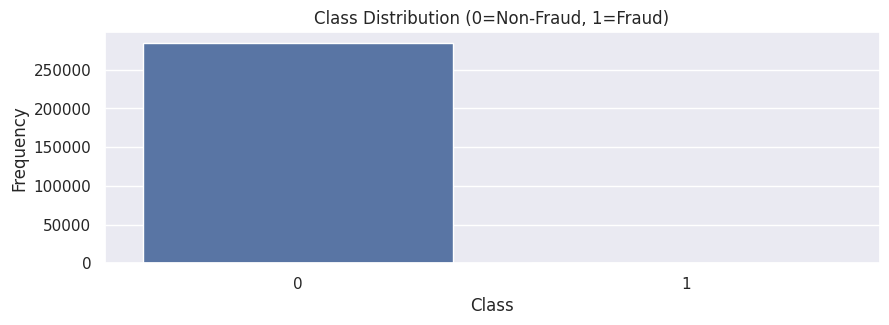

In [ ]:
# Visualize Class imbalance
plt.figure(figsize=(10,3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0=Non-Fraud, 1=Fraud)")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

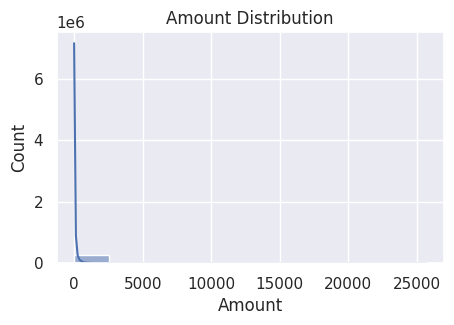

In [ ]:
# Amount distribution (raw)
plt.figure(figsize=(5,3))
sns.histplot(df["Amount"], bins=10, kde=True)
plt.title("Amount Distribution")
plt.show()

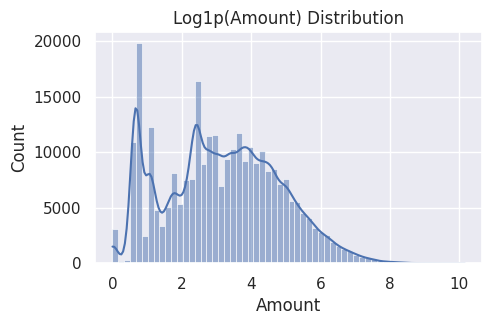

In [ ]:
# Amount Distribution (raw + 1og1p)
plt.figure(figsize=(5,3))
sns.histplot(np.log1p(df["Amount"]), bins=60, kde=True)
plt.title("Log1p(Amount) Distribution")
plt.show()

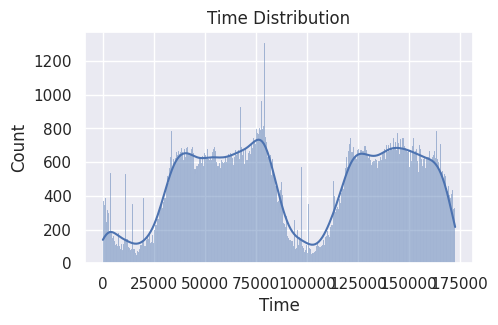

In [ ]:
# Time Distribution
plt.figure(figsize=(5,3))
sns.histplot(df["Time"], bins=600, kde=True)
plt.title("Time Distribution")
plt.show()

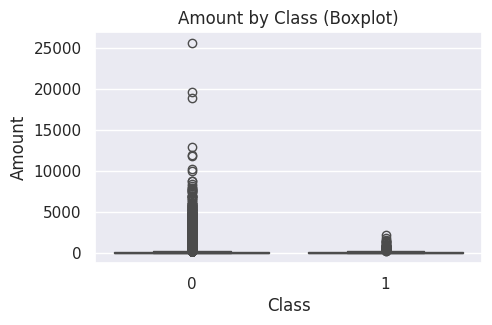

In [ ]:
# Amount by class (helps intuition)
plt.figure(figsize=(5,3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by Class (Boxplot)")
plt.show()

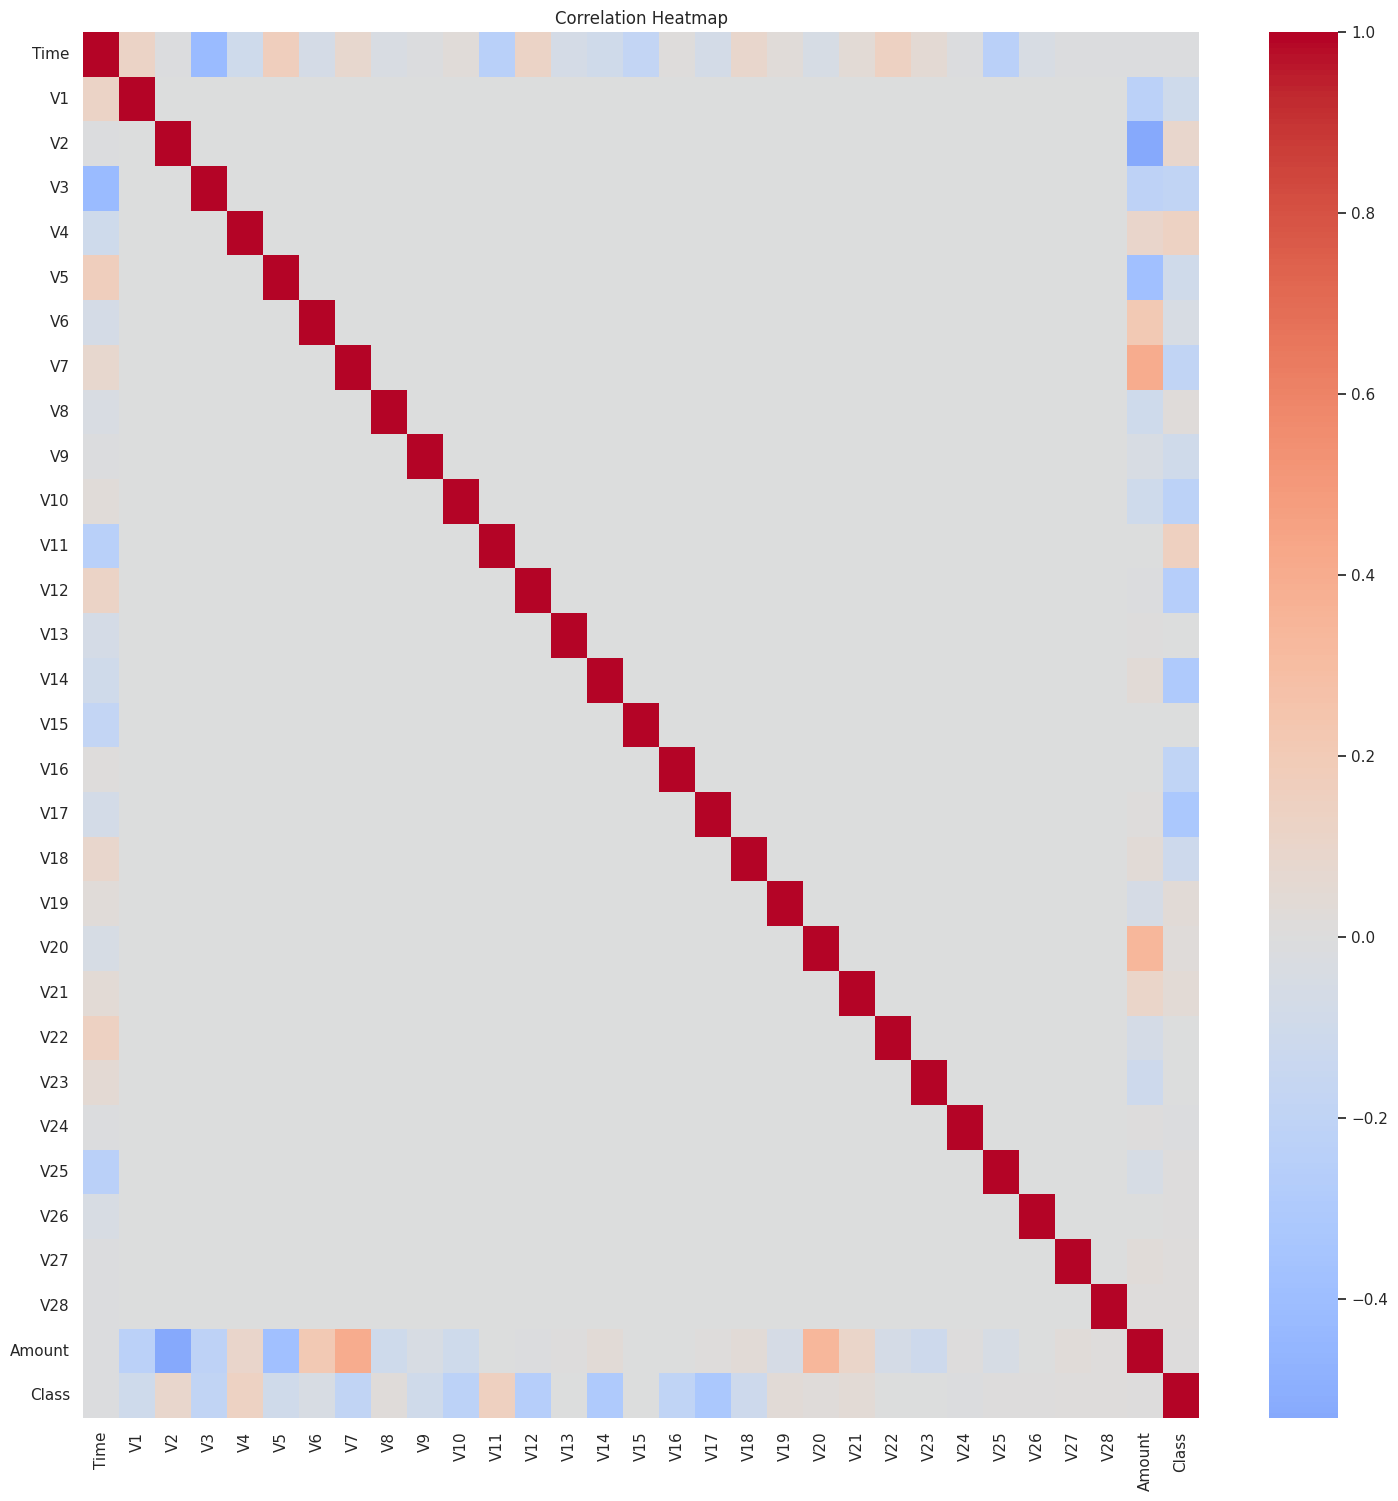

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(18,18))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

There are no highly correlated columns ( probably because PCA was applied to the columns)

In [ ]:
# correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5), corr_target.tail(5)

(Class   1.000
 V11     0.155
 V4      0.133
 V2      0.091
 V21     0.040
 Name: Class, dtype: float64,
 V16   -0.197
 V10   -0.217
 V12   -0.261
 V14   -0.303
 V17   -0.326
 Name: Class, dtype: float64)

**4. Data Preprocessing**

In [ ]:
# Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log1p'],
      dtype='object')

In [ ]:
# Seperate features and target
X = df.drop(columns=["Class", "Amount"])
y = df["Class"]

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [ ]:
print("Dataset Shape:", X.shape)
print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

Dataset Shape: (284807, 30)
Training Set Shape: (227845, 30)
Test Set Shape: (56962, 30)


**5. Baseline Model**

- Since it is a tree model, Scalling is not necessary
- we could use (model = DecisionTreeClassifier()) but pipeline is the best approach ---- if in another dataset you need scaling it can be easily added

In [ ]:
base_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [ ]:
# Train the model
base_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', DecisionTreeClassifier(random_state=42))])

In [ ]:
y_base_train_pred = base_pipeline.predict(X_train)
y_base_test_pred = base_pipeline.predict(X_test)

In [ ]:
base_train_acc = accuracy_score(y_train, y_base_train_pred)
base_test_acc = accuracy_score(y_test, y_base_test_pred)

print("Training Accuracy Score:", base_train_acc)
print("Test Data Accuracy:", base_test_acc)

Training Accuracy Score: 1.0
Test Data Accuracy: 0.9991397773954567


In [ ]:
print("Training Accuracy Score:", round(base_train_acc*100, 2))
print("Test Data Accuracy:", round(base_test_acc*100, 2))

Training Accuracy Score: 100.0
Test Data Accuracy: 99.91


In [ ]:
# Classification Report ---- Good metric to use when there is a class imbalance
print("Train Classification Report")
print(classification_report(y_train, y_base_train_pred))

Train Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [ ]:
print("Test Classification Report")
print(classification_report(y_test, y_base_test_pred))

Test Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Accuracy score is not reliable because of class imbalance

In [ ]:
# Average precision score (or) pr-auc - Training Data
y_train_prob = base_pipeline.predict_proba(X_train)[:,1]

print("Training Average Precision Score:", average_precision_score(y_train, y_train_prob))

Training Average Precision Score: 1.0


In [ ]:
# Average precision score (or) pr-auc - Test Data
y_test_prob = base_pipeline.predict_proba(X_test)[:,1]
print("Test Average Precision Score:", average_precision_score(y_test, y_test_prob))

Test Average Precision Score: 0.5610321985726947


**6. Model Optimization**

In [ ]:
k=5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
models = {
    "dt_balanced":Pipeline(
        [
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced" # telling the model that if it makes a wronng prediction for minority case it gets an higher penality
                )),
        ]
    ),
    "hgb_balanced":Pipeline(
        [
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
                ))
        ]
    ),
    "rfc_balanced":Pipeline(
        [
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
                ))
        ]
    )
}

In [ ]:
for name, m in models.items():

    pr_auc_scores = []

    for train_idx, te_idx in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[te_idx]  # K-fold

        m.fit(X_tr, y_tr)
        pred_prob = m.predict_proba(X_te)[:, 1]

        pr_auc_scores.append(average_precision_score(y_te, pred_prob))

    print("Modle Name:", name)
    print("PR-AUC values:", pr_auc_scores)
    print("CV PR-AUC mean:", round(float(np.mean(pr_auc_scores)), 2))

Modle Name: dt_balanced
PR-AUC values: [np.float64(0.5007266812564823), np.float64(0.4830774702828517), np.float64(0.5797304220740939), np.float64(0.5880053883273093), np.float64(0.5312714890725482)]
CV PR-AUC mean: 0.54
Modle Name: hgb_balanced
PR-AUC values: [np.float64(0.7650653511464124), np.float64(0.7426863047121037), np.float64(0.6961437658687323), np.float64(0.7842427747774444), np.float64(0.7429545175433017)]
CV PR-AUC mean: 0.75
Modle Name: rfc_balanced
PR-AUC values: [np.float64(0.8423466244325414), np.float64(0.8148815259132303), np.float64(0.830418381185712), np.float64(0.8821778726675099), np.float64(0.8271070867780583)]
CV PR-AUC mean: 0.84


Best Model as per model selection process: Random Forest Classifier

**Hyper parameter tuning for Random Forest Classifier**

In [ ]:
rfc_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1, # How many cpu cores do you want to use
        class_weight="balanced_subsample"
    ))
])

In [ ]:
# Hyperparameter tuning - Random Forest Classifier
param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [2, 5, 10, 20],
    "model__max_features": ["sqrt", "log2", 0.4, 0.5]
}

In [ ]:
# random search
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=True
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
print("Best CV PR-AUC:", round(random_search.best_score_, 4))
print("Best Model Params:", random_search.best_params_)

**7. Re-Train with best parameters**

In [ ]:
best_rfc = Pipeline(
    [
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=30,
            min_samples_leaf=1,
            max_features="log2",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [ ]:
# Train Best rfc
best_rfc.fit(X_train, y_train)

**8. Model Evaluation**

In [ ]:
# Training data prediction
y_train_pred = best_rfc.predict(X_train)

In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {round(train_acc*100, 2)}%")

In [ ]:
# Confusion Matrix - Training Data
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Non-Fraud", "Pred Fraud"],
    yticklabels=["Actual Non-Fraud", "Actual Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("Training Classification Report")
print(classification_report(y_train, y_train_pred))

In [ ]:
train_proba = best_rfc.predict_proba(X_train)[:,1]
print("Training PR-AUC:", round(average_precision_score(y_train, train_proba), 4))

In [ ]:
y_test_pred = best_rfc.predict(X_test)

In [ ]:
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {round(test_acc*100, 2)}%")

In [ ]:
# Confusion Matrix _Test Data
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Non-Fraud", "Pred Fraud"],
    yticklabels=["Actual Non-Fraud", "Actual Fraud"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("Test Classification Report")
print(classification_report(y_test, y_test_pred))

In [ ]:
test_proba = best_rfc.predict_proba(X_test)[:,1]
print("Training PR-AUC:", round(average_precision_score(y_test, test_proba), 4))

**9. Build a predictive system**

In [ ]:
def predict_class(input_fesatures):
  input_df = pd.DataFrame(
      input_features,
      columns=X_train.columns,
  )
  # Get prediction from trained model
  prediction = best_rfc.predict(input_df)
  print("Model Prediction:", prediction)
  if prediction[0] == 1:
    print("Fraudulent Transaction Detected")
  else:
    print("Non-Fraudulent Transaction")


In [ ]:
X_test.head()

In [ ]:
y_test.head()

In [ ]:
X_test[y_test == 1].head()

In [ ]:
test_1 = X_test.loc[11378].tolist()
print(test_1)

In [ ]:
predict_class(test_1)

In [ ]:
# we can tune threshold to improve the performance even more